# Notebook for Support Vector Regression and SHAPLY calculation

#### Imports

In [1]:
import pandas as pd
import importlib
from SVR import svr_machine_learning

importlib.reload(svr_machine_learning)

C:\Users\Minh\anaconda3\envs\Psycho_DataspellProjekt\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'SVR.svr_machine_learning' from 'C:\\Users\\Minh\\Desktop\\Psycho Arbeit\\Psycho_DataspellProjekt\\SVR\\svr_machine_learning.py'>

#### Machine Learning Variables

In [4]:
# ===========================
# 🔧 SVR Notebook Settings
# ===========================

my_target_column = "How happy are you?"
my_test_size = 0.2
my_random_state = 42

# SVR baseline parameters
my_svr_kernel = "rbf"
my_svr_C = 1.0
my_svr_epsilon = 0.1

# SHAP settings
my_number_of_shaply_rows = 5000
my_number_header_rows = 150

##### Model 1A Optimized

In [5]:
# Load data
data = pd.read_csv('../data/data_eqls_LOOSE_filtered.csv')

model_1A_optimized, shap_results_1A_optimized = svr_machine_learning.run_svr_gridsearch_and_shap(
    df=data,
    target_column=my_target_column,
    test_size=my_test_size,
    random_state=my_random_state,
    shap_rows=my_number_of_shaply_rows,
    number_header_rows=my_number_header_rows
)


Fitting 3 folds for each of 9 candidates, totalling 27 fits
✅ RMSE: 1.2884
✅ R²: 0.4191
🔍 Starting SHAP for 5000 rows...


 11%|█         | 134/1225 [04:27<36:12,  1.99s/it] C:\Users\Minh\anaconda3\envs\Psycho_DataspellProjekt\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=1.017e-02, with an active set of 8 regressors, and the smallest cholesky pivot element being 8.429e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
 44%|████▍     | 545/1225 [18:34<24:04,  2.12s/it]  C:\Users\Minh\anaconda3\envs\Psycho_DataspellProjekt\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=7.206e-03, with an active set of 4 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
 56%|█████▋    | 691/1225 [23:34<34:56,  3.93s/it]C:\Users\Minh\anaconda3\envs\Psycho_DataspellProjekt\Lib\site-packages\


Top SHAP features:
                                          Questions     Value  Direction
121                 How satisfied with family life?  0.140466  -0.045360
119  How satisfied with present standard of living?  0.122727  -0.004196
123                 How satisfied with social life?  0.106334  -0.014836
30                                 Health condition  0.056902  -0.007381
122                      How satisfied with health?  0.038508  -0.007922
..                                              ...       ...        ...
51       Difficult to see a doctor because of cost?  0.002346   0.000663
134                                 Country_Belgium  0.002336   0.000689
16                                    Country group  0.002286   0.000242
34              Problems with accommodation - space  0.002157  -0.000139
21             Phone/internet contact with children  0.002040   0.000673

[150 rows x 3 columns]

✅ Best Parameters: {'C': 1, 'epsilon': 0.2, 'kernel': 'rbf'}


In [6]:
# Save results
shap_results_1A_optimized.to_csv("Results/shap_results_1A_opzimized.csv", index=False)

##### Model 1B - No 'How satisfied with...' questions - Hyperparameter optimized

In [7]:
# Load data
data = pd.read_csv('../data/data_eqls_LOOSE_filtered.csv')
my_target_column = 'How happy are you?'
print("Shape before: ", data.shape)

# Drop 'How satisfied with...' columns
# They have too much predictive value and there are similar questions
# e.g. "Health condition", "Quality of education system?", "Feel left out of sociey?"
columns_to_remove = [
    'How satisfied with present standard of living?',
    'How satisfied with family life?',
    'How satisfied with social life?',
    'How satisfied with health?',
    'How satisfied with economic situation in the country?',
    'How satisfied with accommodation?',
    'How satisfied with education?'
]
data.drop(columns=columns_to_remove, inplace=True, errors='ignore')
print("Shape after: ", data.shape)

model_1B_optimized, shap_results_1B_optimized = svr_machine_learning.run_svr_gridsearch_and_shap(
    df=data,
    target_column=my_target_column,
    test_size=my_test_size,
    random_state=my_random_state,
    cv_folds=3,
    shap_rows=my_number_of_shaply_rows,
    number_header_rows=my_number_header_rows
)

Shape before:  (6122, 168)
Shape after:  (6122, 162)
Fitting 3 folds for each of 9 candidates, totalling 27 fits
✅ RMSE: 1.4029
✅ R²: 0.3113
🔍 Starting SHAP for 5000 rows...


 11%|█▏        | 140/1225 [05:31<48:12,  2.67s/it] C:\Users\Minh\anaconda3\envs\Psycho_DataspellProjekt\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. alpha=2.160e-02, with an active set of 5 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
 24%|██▍       | 295/1225 [12:14<40:36,  2.62s/it]  C:\Users\Minh\anaconda3\envs\Psycho_DataspellProjekt\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=6.006e-03, with an active set of 9 regressors, and the smallest cholesky pivot element being 8.429e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
 33%|███▎      | 407/1225 [17:12<32:48,  2.41s/it]  C:\Users\Minh\anaconda3\envs\Psycho_DataspellProjekt\Lib\site-package


Top SHAP features:
                                             Questions     Value  Direction
30                                    Health condition  0.125577  -0.004223
118                      How satisfied with education?  0.076306  -0.008478
115  I generally feel that what I do in life is wor...  0.061370   0.005668
116     I feel I am free to decide how to live my life  0.043247  -0.014133
114                   I am optimistic about the future  0.032879   0.000838
..                                                 ...       ...        ...
152                                   Country_Portugal  0.002083  -0.002083
41                      Neighbourhood problems - noise  0.002037  -0.000533
157                                      Country_Spain  0.001869   0.000258
148                                      Country_Malta  0.001692  -0.001692
129                                   Country_Bulgaria  0.001302  -0.001302

[150 rows x 3 columns]

✅ Best Parameters: {'C': 1, 'epsilon': 0.2,

In [8]:
# Save results
shap_results_1B_optimized.to_csv("Results/shap_results_1B_opzimized.csv", index=False)

# Plots

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap

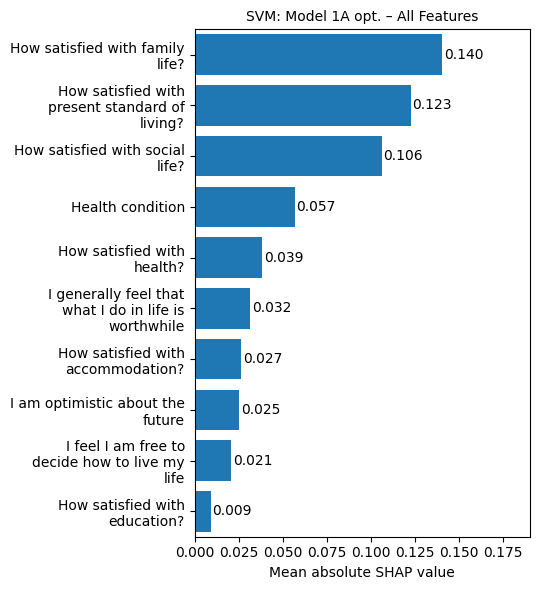

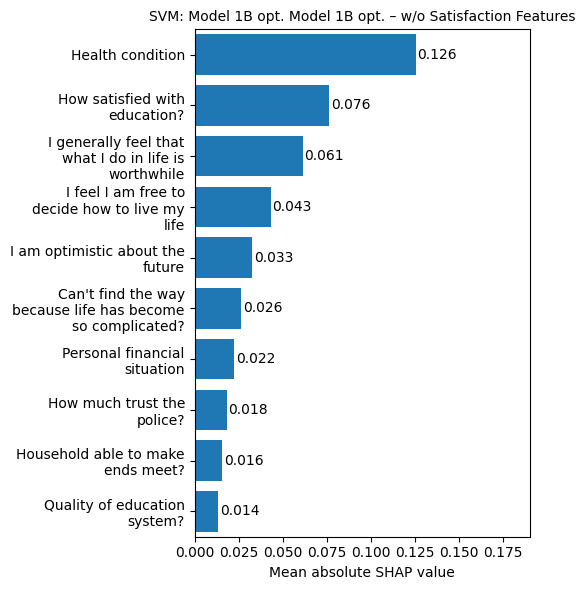

In [11]:
# Load Data
df_1A = pd.read_csv("Results/shap_results_1A_opzimized.csv")
df_1B = pd.read_csv("Results/shap_results_1B_opzimized.csv")

def plot_shap_large(df, title, max_questions=None):

    # # Summarize countries in to one group
    # country_mask = df["Questions"].str.contains("Country_")
    # country_total = df.loc[country_mask, "Value"].sum()
    # # Alle Country_* Zeilen entfernen
    # df = df.loc[~country_mask].copy()
    # df = pd.concat([
    #     df,
    #     pd.DataFrame([{
    #         "Questions": "Country Effects",
    #         "Value": country_total,
    #         "Direction": 0  # optional
    #     }])
    # ], ignore_index=True)
    #
    df_sorted = df.sort_values(by="Value", ascending=True).reset_index(drop=True)
    if max_questions:
        df_sorted = df_sorted.tail(max_questions).reset_index(drop=True)

    df_sorted["Questions"] = df_sorted["Questions"].apply(lambda x: "\n".join(textwrap.wrap(x, width=25)))

    n = len(df_sorted)
    plt.figure(figsize=(5.5, n * 0.6))
    bars = plt.barh(df_sorted["Questions"], df_sorted["Value"])

    # title
    plt.xlabel("Mean absolute SHAP value", color='black', fontsize=10)
    plt.title(title, color='black', fontsize=10)

    xlim_max = max(
        df_1A["Value"].max(),
        df_1B["Value"].max()
    )
    plt.xlim(0, xlim_max+0.05)

    # Display values in the bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001,
                 bar.get_y() + bar.get_height() / 2,
                 f"{width:.3f}",
                 va='center', fontsize=10)

    plt.ylim(-0.5, n - 0.5)
    plt.tight_layout()
    plt.show()

# Show plots
plot_shap_large(df_1A, "SVM: Model 1A opt. – All Features", max_questions=10)
plot_shap_large(df_1B, "SVM: Model 1B opt. Model 1B opt. – w/o Satisfaction Features", max_questions=10)
plt.show()